# General notebook preparation: Libaries and Datasets

At the beginning, the basic libaries that we work with need to be imported. That includes pandas for data read out, matplot libary for basic plotting, numpy for numeric operations, seaborn for advanced plotting and scipy stats for statistical calculations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

Here, our cleaned-up and filtered ATAC-seq dataset is imported.

In [12]:
ATAC_path_pfiltered = Path('data') / 'ATAC_pfiltered.csv'
ATAC_pfiltered = pd.read_csv(ATAC_path_pfiltered)

Here, the QC data from the mmc1 dataset is imported.

In [15]:
mmc1_path = Path('data') / 'mmc1.xlsx'
mmc1_data = pd.read_excel(mmc1_path)
mmc1_data


,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
4,proB.CLP.BM#1,proB.CLP.BM,Hardy,B,B Cell,Bone Marrow,CD19-IgM-CD43+CD24-CD45R-CD93+CD117+IL7Ra+PI-D...,10000,23578208,7.67,6588564,13.21,0.868
...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,BEC.SLN#2,BEC.SLN,Turley,stroma,Blood endothelial cell,skin draining Lymph Node,"CalceinBlue+PDPN-CD31+LiveDead-Lin(CD45,Ter119...",10000,48817892,5.28,13919088,8.22,0.846
177,LEC.SLN#1,LEC.SLN,Turley,stroma,Lymphatic endothelial cell,skin draining Lymph Node,"CalceinBlue+PDPN+CD31+LiveDead-Lin(CD45,Ter119...",10000,26209960,9.75,6892247,6.58,0.887
178,LEC.SLN#2,LEC.SLN,Turley,stroma,Lymphatic endothelial cell,skin draining Lymph Node,"CalceinBlue+PDPN+CD31+LiveDead-Lin(CD45,Ter119...",10000,34577292,4.00,9811569,4.03,0.887
179,Ep.MEChi.Th#1,Ep.MEChi.Th,CBDM,stroma,Thymus mTEC,Thyums,CD45-Ly51loMHCIIhiEPCAMhiDAPI-,10000,18331518,10.26,5783345,12.72,0.915


# Exploration of ATACseq QC Data

In [7]:
mmc1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  181 non-null    str    
 1   CellType                                    181 non-null    str    
 2   ImmGenLab                                   181 non-null    str    
 3   Lineage                                     181 non-null    str    
 4   CellFamily                                  181 non-null    str    
 5   Organ                                       181 non-null    str    
 6   SortingMarkers                              181 non-null    str    
 7   InputCellNumber                             181 non-null    int64  
 8   PF.reads                                    181 non-null    int64  
 9   %chrM.mapped                                181 non-null    float64
 10  Paired.read.after.removin

While 181 cell samples are contained in the metadata, only 90 are retained in the filtered ATAC dataset.

### Filter QC Data to Match ATACseq Dataset

Only samples that are present in the filtered ATACseq data are kept.

In [16]:
mmc1_kept = mmc1_data[mmc1_data["CellType"].isin(ATAC_pfiltered.columns)].copy()
mmc1_kept.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  179 non-null    str    
 1   CellType                                    179 non-null    str    
 2   ImmGenLab                                   179 non-null    str    
 3   Lineage                                     179 non-null    str    
 4   CellFamily                                  179 non-null    str    
 5   Organ                                       179 non-null    str    
 6   SortingMarkers                              179 non-null    str    
 7   InputCellNumber                             179 non-null    int64  
 8   PF.reads                                    179 non-null    int64  
 9   %chrM.mapped                                179 non-null    float64
 10  Paired.read.after.removing.PCR

The samples that were removed from the original metadata are identified.

In [17]:
mmc1_dropped = mmc1_data[~mmc1_data["CellType"].isin(ATAC_pfiltered.columns)].copy()
mmc1_dropped.head()

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
171,FRC.CD140a+.Madcam-.CD35-.SLN#1,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,25768696,6.16,8039453,7.65,0.897
172,FRC.CD140a+.Madcam-.CD35-.SLN#2,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,66673554,6.87,15351027,7.40,0.897


It was noted that stromal fibroblastic reticular cells were among the removed populations

### Check Sequencing Depth (PF reads) 

According to the original paper by Yoshida et al., the minimum threshold for PF reads was set to 2,470,102.<br>
It is verified whether this threshold is passed by all retained samples.

In [18]:
mmc1_data["PF.reads"].describe()

count    1.810000e+02
mean     2.459027e+07
std      6.575663e+06
min      1.614223e+07
25%      2.104140e+07
50%      2.319932e+07
75%      2.587249e+07
max      6.667355e+07
Name: PF.reads, dtype: float64

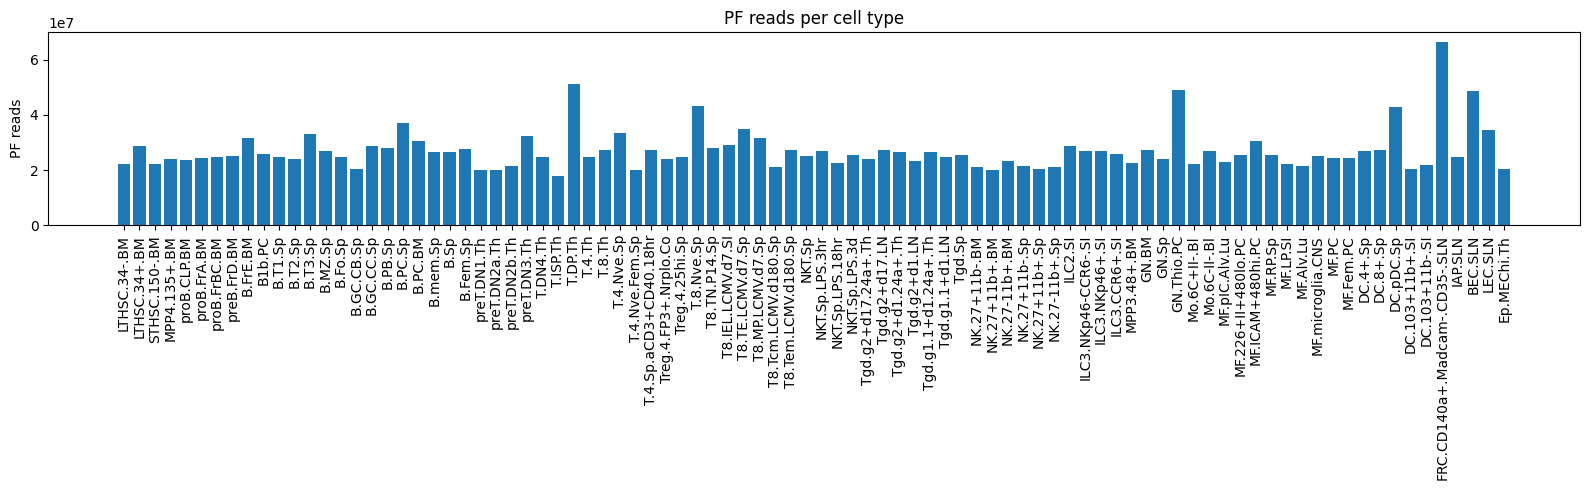

In [19]:
plt.figure(figsize=(16,5))
plt.bar(mmc1_data["CellType"], mmc1_data["PF.reads"])
plt.xticks(rotation=90)
plt.ylabel("PF reads")
plt.title("PF reads per cell type")
plt.tight_layout()
plt.show()

A minimum read count of 16 million was observed, which is well above the paper's threshold.

### Missing Values Analysis

Missing QC metrics for the kept samples are identified.

In [20]:
#number of missing data points per column
missing_values_count_mmc1 = mmc1_data.isnull().sum()
missing_values_count_mmc1[missing_values_count_mmc1 > 0] #just show columes where data is missing

Replicate.cor    5
dtype: int64

Missing values in the 'Replicate.cor' (replicate correlation) column are observed. 
These likely correspond to cell types for which no biological replicates were available.

In [21]:
mmc1_data[mmc1_data["Replicate.cor"].isnull()]

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
127,MPP3.48+.BM#1,MPP3.48+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48+,10000,22469306,3.91,7429716,9.25,NaN


### Distribution of QC Metrics

The distributions of the main ATAC-seq QC metrics are visualized to ensure data quality.

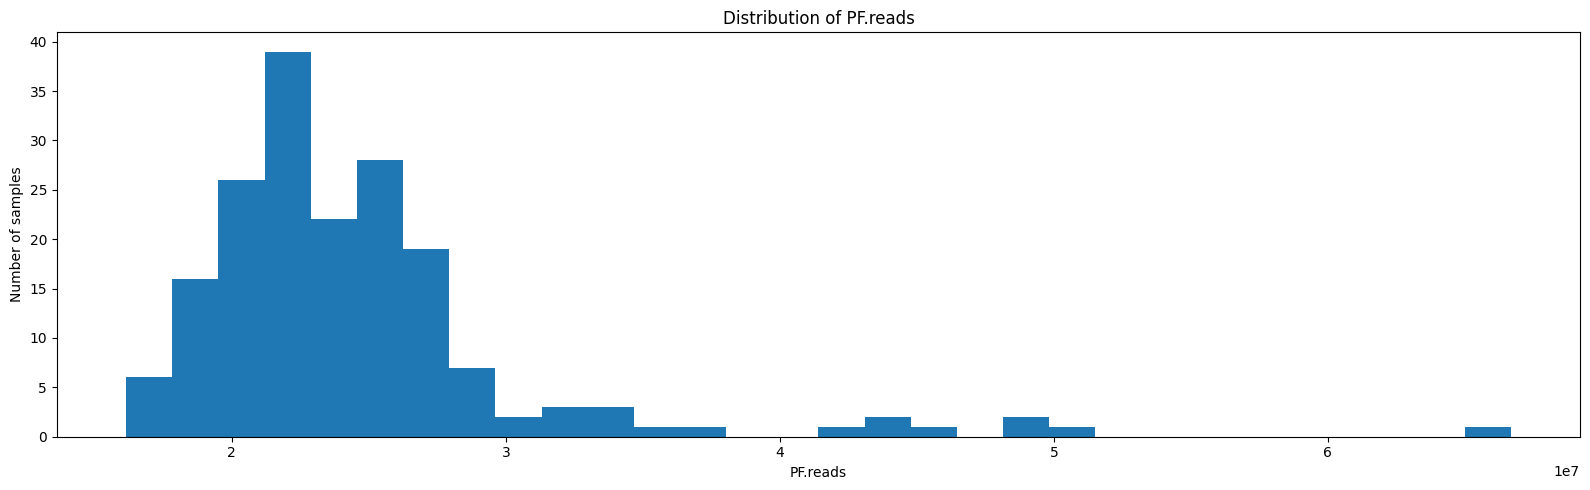

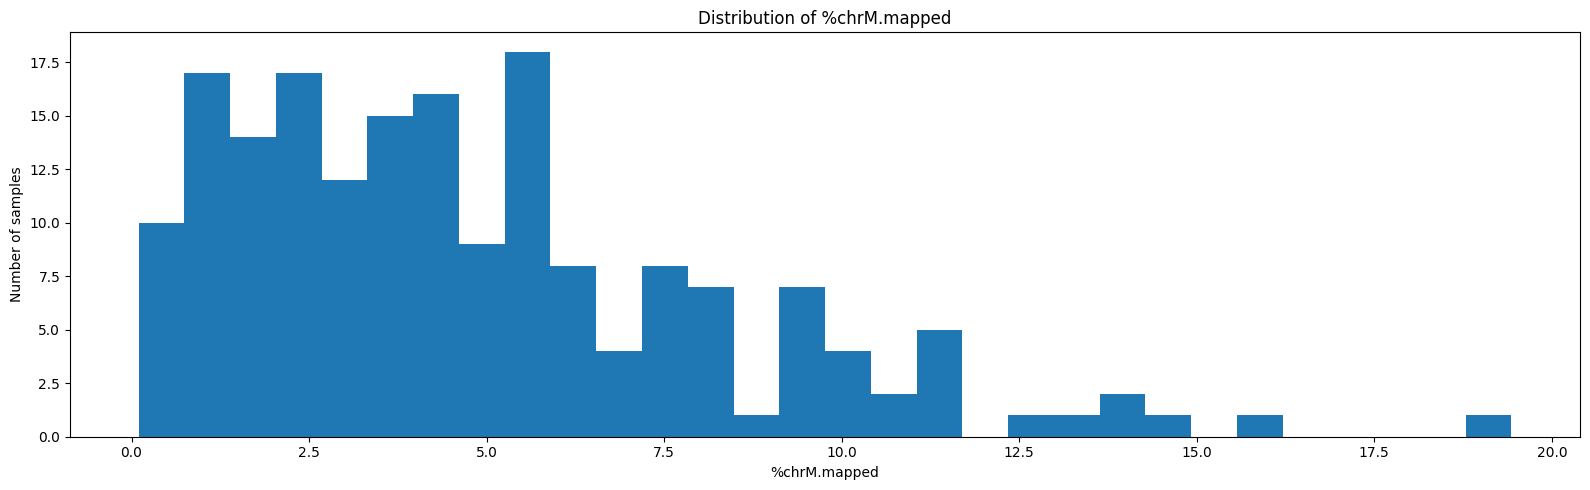

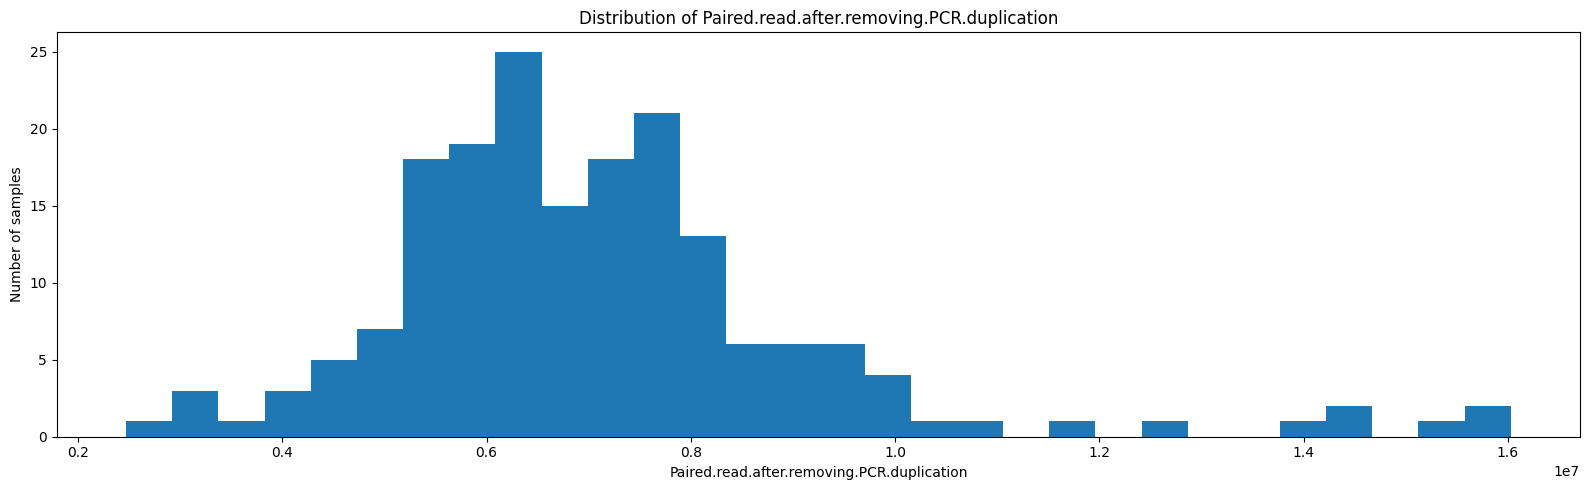

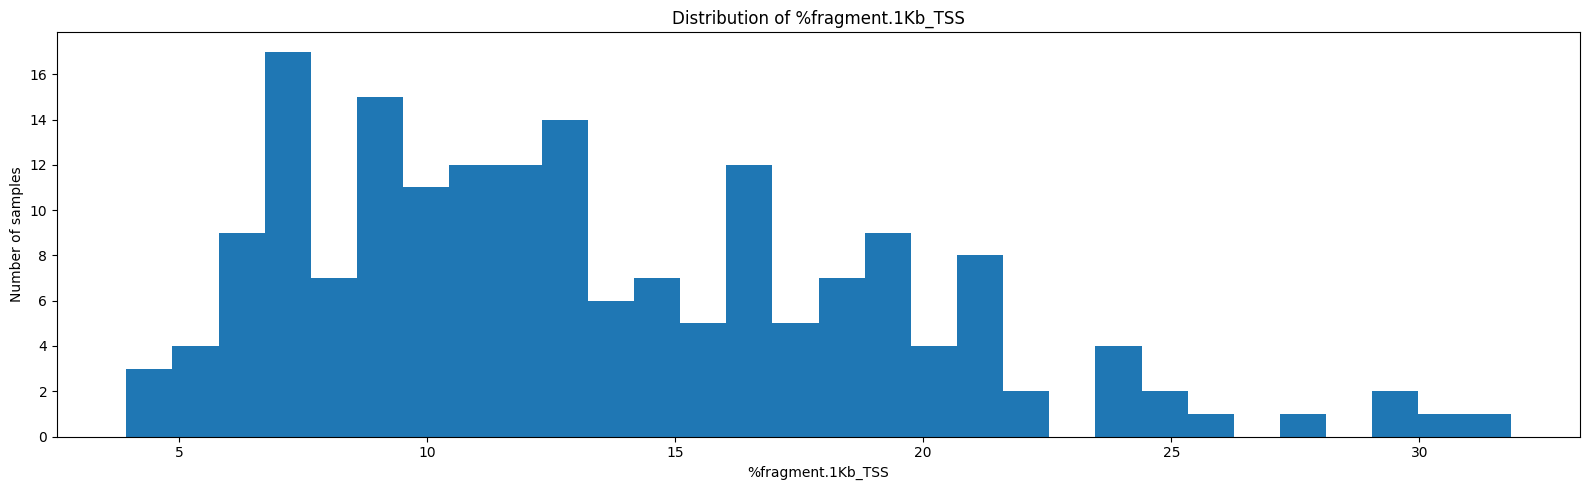

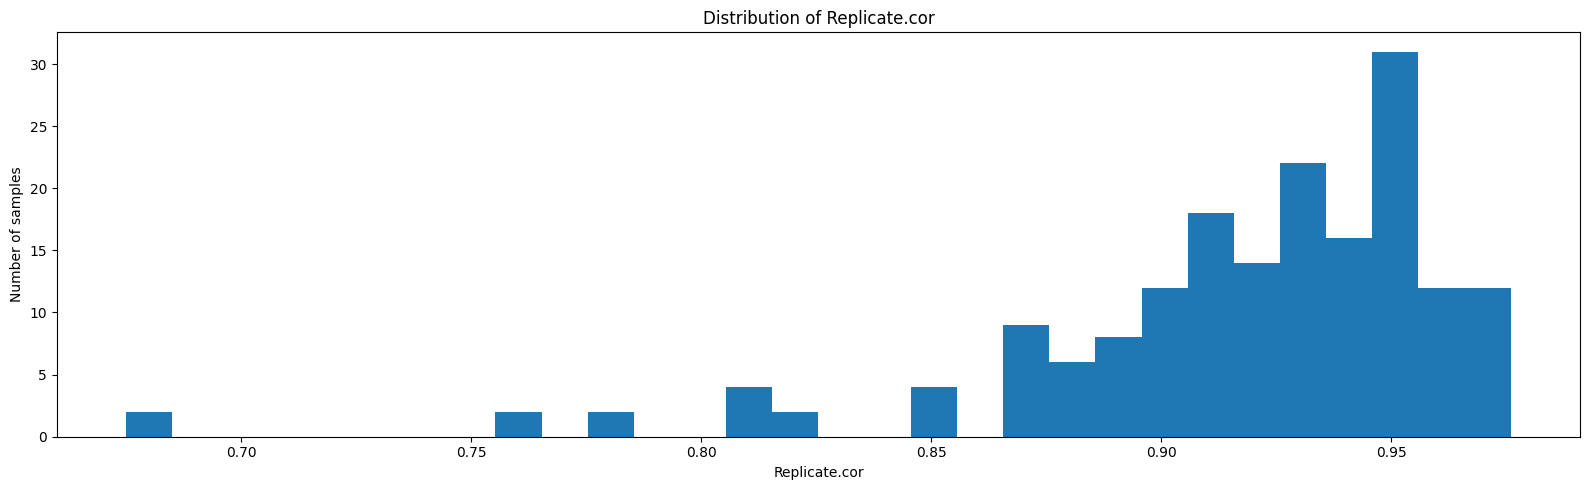

In [ ]:
mmc1_parameter = [
    "PF.reads",
    "%chrM.mapped",
    "Paired.read.after.removing.PCR.duplication",
    "%fragment.1Kb_TSS",
    "Replicate.cor"
]

for parameter in mmc1_parameter:
    plt.figure(figsize=(16,5))
    plt.hist(mmc1_data[parameter].dropna(), bins=30)
    plt.xlabel(parameter)
    plt.ylabel("Number of samples")
    plt.title(f"Distribution of {parameter}" ) # f-String: variable in geschweiften Klammern, setzt Werte automatisch ein
    plt.tight_layout()
    plt.show()



<div class="alert alert-block alert-info">
Conclusion: According to the QC thresholds established in the paper, the distributions of the QC metrics are considered satisfactory.
</div>